In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df =pd.read_csv('insurance.csv')

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#EDA 

In [5]:
df.shape 

(1338, 7)

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

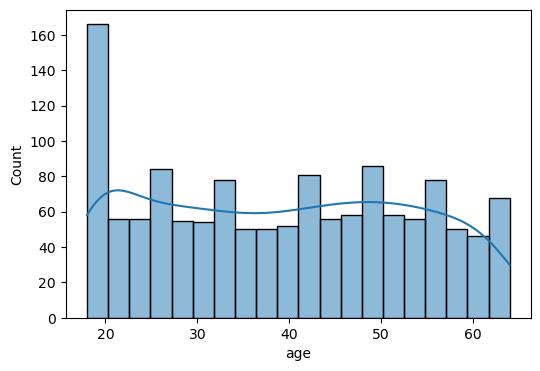

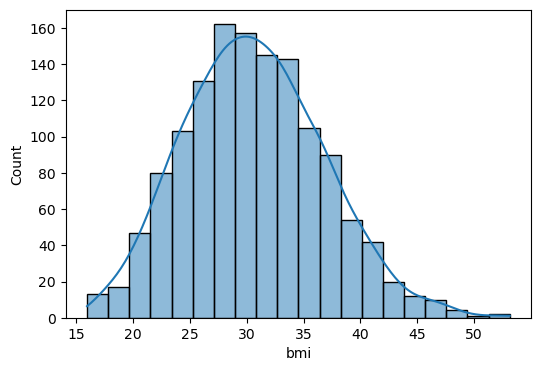

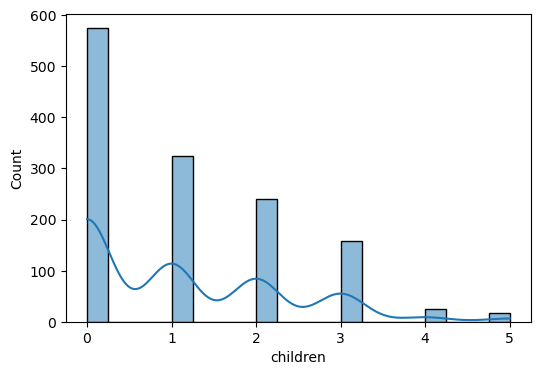

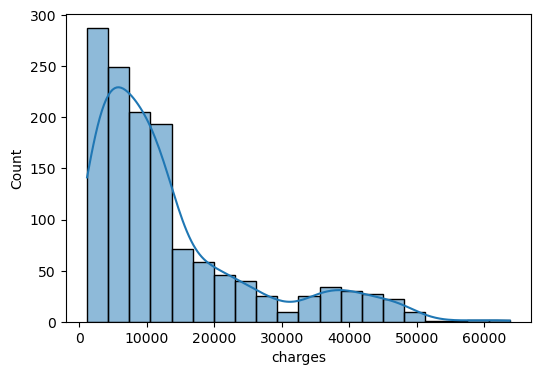

In [11]:
numeric_cols=['age', 'bmi', 'children', 'charges']
for cols in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[cols],kde=True,bins=20)

<Axes: ylabel='count'>

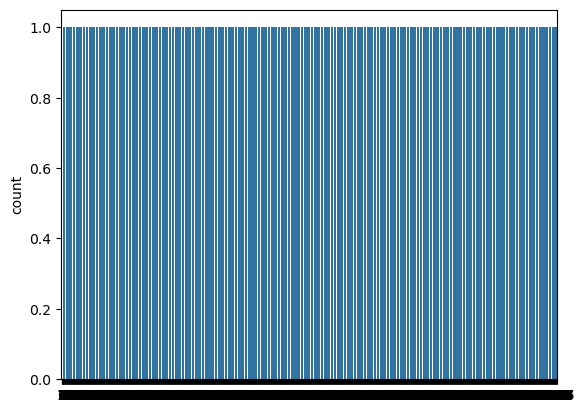

In [12]:
sns.countplot(df['children'])

<Axes: xlabel='sex', ylabel='count'>

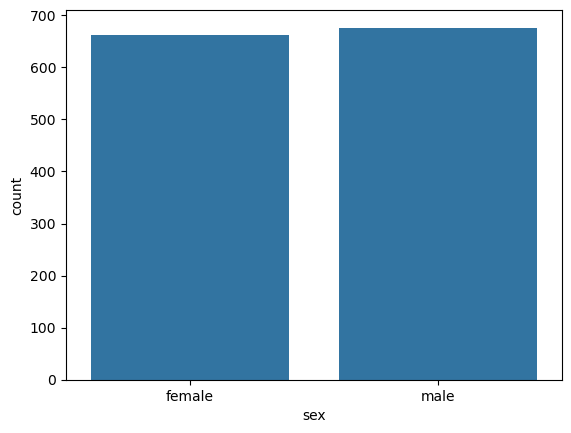

In [13]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

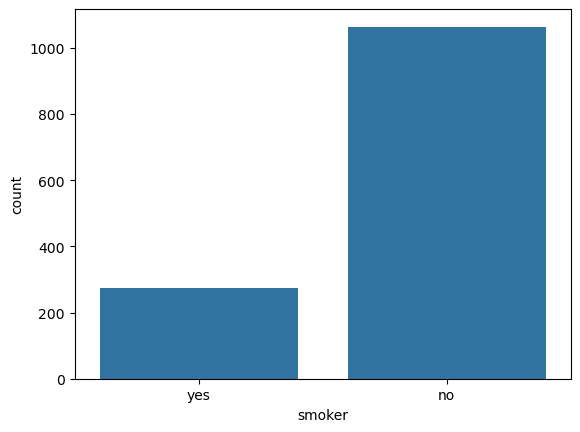

In [14]:
sns.countplot(x=df['smoker'])

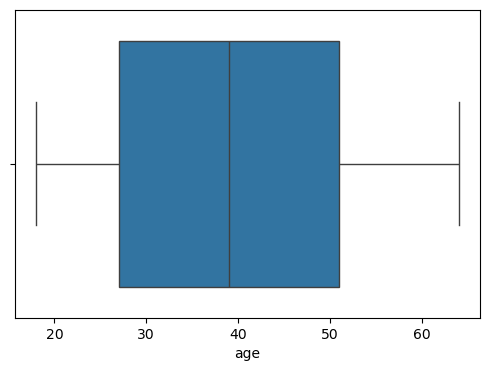

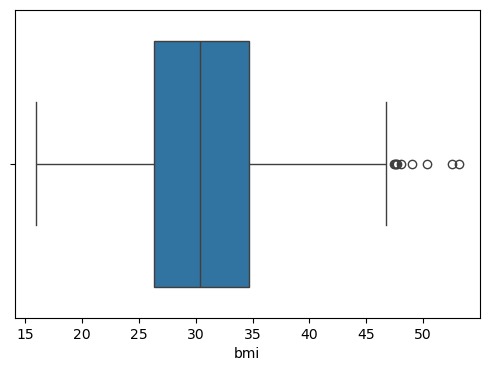

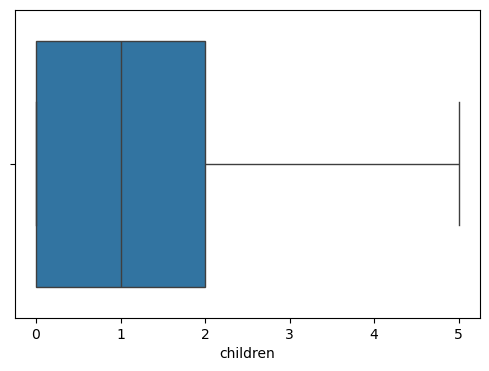

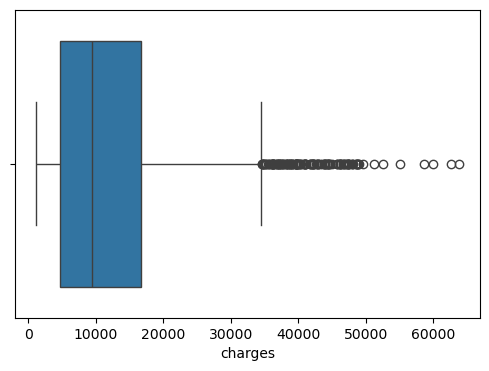

In [15]:
for cols in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[cols])

<Axes: >

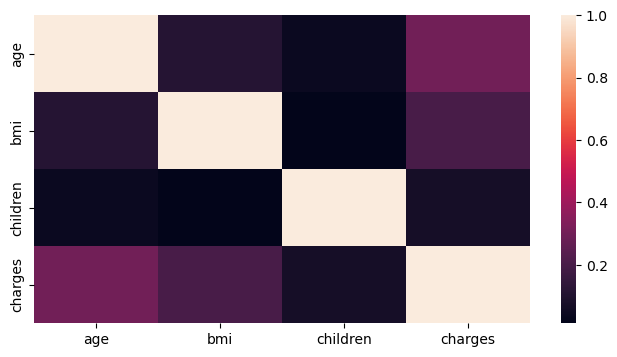

In [16]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True))

#data cleanign and processing

In [17]:
df_data=df.copy()

In [18]:
df_data.drop_duplicates(inplace=True)

In [19]:
df_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [20]:
df.shape 

(1338, 7)

In [21]:
df_data.shape 

(1337, 7)

In [22]:
df_data.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [23]:
df_data['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [24]:
#label encodeing alpha to numeric 

In [25]:
df_data['sex']=df_data['sex'].map({'male':0,'female':1})

In [26]:
df_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [27]:
df_data['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [28]:
df_data['smoker']=df_data['smoker'].map({'yes':1,'no':1})

In [29]:
df_data

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [30]:
df_data.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker',
},inplace=True)

In [31]:
df_data

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [32]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [33]:
#one hot encodeing 

In [34]:
df_data=pd.get_dummies(df_data,columns=['region'])

In [35]:
df_data

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,1,1725.55230,False,False,True,False
2,28,0,33.000,3,1,4449.46200,False,False,True,False
3,33,0,22.705,0,1,21984.47061,False,True,False,False
4,32,0,28.880,0,1,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,10600.54830,False,True,False,False
1334,18,1,31.920,0,1,2205.98080,True,False,False,False
1335,18,1,36.850,0,1,1629.83350,False,False,True,False
1336,21,1,25.800,0,1,2007.94500,False,False,False,True


In [36]:
df_data=df_data.astype(int)

In [37]:
df_data

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,1,1725,0,0,1,0
2,28,0,33,3,1,4449,0,0,1,0
3,33,0,22,0,1,21984,0,1,0,0
4,32,0,28,0,1,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,0,1,0,0
1334,18,1,31,0,1,2205,1,0,0,0
1335,18,1,36,0,1,1629,0,0,1,0
1336,21,1,25,0,1,2007,0,0,0,1


#featuer engineering and extraction

In [38]:
df_data['bmi_cat']=pd.cut(
    df_data['bmi'],
    bins=[0, 18.5, 24.9,29.9,float('inf')],
    labels=['Underweight','Normal','obese','very fat']


)

In [39]:
df_data

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat
0,19,1,27,0,1,16884,0,0,0,1,obese
1,18,0,33,1,1,1725,0,0,1,0,very fat
2,28,0,33,3,1,4449,0,0,1,0,very fat
3,33,0,22,0,1,21984,0,1,0,0,Normal
4,32,0,28,0,1,3866,0,1,0,0,obese
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,0,1,0,0,very fat
1334,18,1,31,0,1,2205,1,0,0,0,very fat
1335,18,1,36,0,1,1629,0,0,1,0,very fat
1336,21,1,25,0,1,2007,0,0,0,1,obese


In [40]:
(df_data['bmi_cat']=='Underweight').sum()

np.int64(24)

In [41]:
df_data=pd.get_dummies(df_data,columns=['bmi_cat'])

In [42]:
df_data

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_Underweight,bmi_cat_Normal,bmi_cat_obese,bmi_cat_very fat
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,1,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,1,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,1,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,1,3866,0,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,0,1,0,0,False,False,False,True
1334,18,1,31,0,1,2205,1,0,0,0,False,False,False,True
1335,18,1,36,0,1,1629,0,0,1,0,False,False,False,True
1336,21,1,25,0,1,2007,0,0,0,1,False,False,True,False


In [43]:
df_data=df_data.astype(int)

In [44]:
df_data

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_Underweight,bmi_cat_Normal,bmi_cat_obese,bmi_cat_very fat
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,1,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,1,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,1,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,1,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,1,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,1,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,1,2007,0,0,0,1,0,0,1,0


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
cols=['age','bmi','children']
scaler=StandardScaler()
df_data[cols]=scaler.fit_transform(df_data[cols])
df_data

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_Underweight,bmi_cat_Normal,bmi_cat_obese,bmi_cat_very fat
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,1,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,1,10600,0,1,0,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,1,2205,1,0,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,1,1629,0,0,1,0,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,1,2007,0,0,0,1,0,0,1,0


In [47]:
df_data.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_Underweight,bmi_cat_Normal,bmi_cat_obese,bmi_cat_very fat
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,1,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,0,1,0,0,0,0,1,0


In [48]:
from scipy.stats import pearsonr

In [51]:
df_data.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_cat_Underweight', 'bmi_cat_Normal',
       'bmi_cat_obese', 'bmi_cat_very fat'],
      dtype='object')

In [52]:
selected_feature=[
    'age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
    'region_northeast', 'region_northwest', 'region_southeast',
   'region_southwest', 'bmi_cat_Underweight', 'bmi_cat_Normal',
    'bmi_cat_obese', 'bmi_cat_very fat'
]

In [54]:
corr = df_data.select_dtypes(include='number').corr(method='pearson')['charges'].sort_values(ascending=False)

print(corr)

charges                1.000000
age                    0.298309
bmi_cat_very fat       0.200348
bmi                    0.196236
region_southeast       0.073577
children               0.067390
region_northeast       0.005946
region_northwest      -0.038695
region_southwest      -0.043637
bmi_cat_Underweight   -0.050599
is_female             -0.058046
bmi_cat_Normal        -0.104042
bmi_cat_obese         -0.120601
is_smoker                   NaN
Name: charges, dtype: float64


In [56]:
corr_df = corr.to_frame(name='Pearson_Correlation')
corr_df

,Pearson_Correlation
charges,1.000000
age,0.298309
bmi_cat_very fat,0.200348
bmi,0.196236
region_southeast,0.073577
children,0.067390
region_northeast,0.005946
region_northwest,-0.038695
region_southwest,-0.043637
bmi_cat_Underweight,-0.050599


In [57]:
corr_df = corr.rename_axis('Feature').reset_index(name='Pearson_Correlation')
corr_df

,Feature,Pearson_Correlation
0,charges,1.000000
1,age,0.298309
2,bmi_cat_very fat,0.200348
3,bmi,0.196236
4,region_southeast,0.073577
5,children,0.067390
6,region_northeast,0.005946
7,region_northwest,-0.038695
8,region_southwest,-0.043637
9,bmi_cat_Underweight,-0.050599


In [59]:
df_data.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_Underweight,bmi_cat_Normal,bmi_cat_obese,bmi_cat_very fat
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,1,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,0,1,0,0,0,0,1,0


In [61]:
print(df_data['is_smoker'].dtype)

int64


In [63]:
print(df_data['is_smoker'].value_counts(dropna=False))

is_smoker
1    1337
Name: count, dtype: int64


In [64]:
print(df_data['is_smoker'].nunique())

1


In [66]:
df_data['is_smoker'] = df_data['is_smoker'].map({'yes': 1, 'no': 0})

In [69]:
corr_df = df.select_dtypes(include='number').corr(method='pearson')
corr_df

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [70]:
corr_df = (
    df.select_dtypes(include='number')
      .corr(method='pearson')['charges']
      .rename_axis('Feature')
      .reset_index(name='Pearson_Correlation')
)

corr_df

,Feature,Pearson_Correlation
0,age,0.299008
1,bmi,0.198341
2,children,0.067998
3,charges,1.000000


In [72]:
corr_df = df_data[selected_feature].corr(method='pearson')
corr_df

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_cat_Underweight,bmi_cat_Normal,bmi_cat_obese,bmi_cat_very fat
age,1.000000,0.019814,0.108491,0.041536,NaN,0.298309,0.001868,0.001495,-0.012311,0.009415,-0.077174,-0.072444,-0.013608,0.086781
is_female,0.019814,1.000000,-0.046541,-0.017848,NaN,-0.058046,0.002008,0.012482,-0.017578,0.003767,0.023849,0.022450,0.026002,-0.046651
bmi,0.108491,-0.046541,1.000000,0.011081,NaN,0.196236,-0.138905,-0.138620,0.271328,-0.004325,-0.286342,-0.581889,-0.322700,0.802051
children,0.041536,-0.017848,0.011081,1.000000,NaN,0.067390,-0.023202,0.026044,-0.023492,0.021538,-0.006066,0.013103,-0.020481,0.010455
is_smoker,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,0.298309,-0.058046,0.196236,0.067390,NaN,1.000000,0.005946,-0.038695,0.073577,-0.043637,-0.050599,-0.104042,-0.120601,0.200348
region_northeast,0.001868,0.002008,-0.138905,-0.023202,NaN,0.005946,1.000000,-0.319842,-0.345909,-0.320493,0.068152,0.086674,0.017176,-0.098209
region_northwest,0.001495,0.012482,-0.138620,0.026044,NaN,-0.038695,-0.319842,1.000000,-0.345909,-0.320493,0.028712,0.039682,0.051843,-0.084223
region_southeast,-0.012311,-0.017578,0.271328,-0.023492,NaN,0.073577,-0.345909,-0.345909,1.000000,-0.346614,-0.082693,-0.086709,-0.093030,0.170958
region_southwest,0.009415,0.003767,-0.004325,0.021538,NaN,-0.043637,-0.320493,-0.320493,-0.346614,1.000000,-0.010952,-0.036245,0.027591,0.004836


In [74]:
corr_df = (
    df_data[selected_feature]
    .corr(method='pearson')['charges']
    .drop('charges')
    .rename_axis('Feature')
    .reset_index(name='Pearson_Correlation')
)

corr_df

,Feature,Pearson_Correlation
0,age,0.298309
1,is_female,-0.058046
2,bmi,0.196236
3,children,0.067390
4,is_smoker,NaN
5,region_northeast,0.005946
6,region_northwest,-0.038695
7,region_southeast,0.073577
8,region_southwest,-0.043637
9,bmi_cat_Underweight,-0.050599


In [75]:
df_data['is_smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [78]:
df_data['is_smoker'].value_counts(dropna=False)

is_smoker
0    1063
1     274
Name: count, dtype: int64

In [79]:
corr = df_data[selected_feature].corr(method='pearson')['charges']

corr_df = (
    corr.drop('charges')
        .rename_axis('Feature')
        .reset_index(name='Pearson_Correlation')
        .sort_values('Pearson_Correlation', ascending=False)
        .reset_index(drop=True)
)

corr_df

,Feature,Pearson_Correlation
0,is_smoker,0.787234
1,age,0.298309
2,bmi_cat_very fat,0.200348
3,bmi,0.196236
4,region_southeast,0.073577
5,children,0.067390
6,region_northeast,0.005946
7,region_northwest,-0.038695
8,region_southwest,-0.043637
9,bmi_cat_Underweight,-0.050599


In [80]:
cat_features=[
    'is_smoker','is_female',
    'region_northwest','region_southwest','region_southeast',
    'bmi_cat_obese','bmi_cat_Normal','bmi_cat_Underweight'
]

In [81]:
from scipy.stats import chi2_contingency

In [82]:
alpha=0.05

In [84]:
df_data['charges_bin'] = pd.qcut(df['charges'], q=4, labels=[
    'Low', 'Medium', 'High', 'Very High'
])

In [91]:
import pandas as pd
from scipy.stats import chi2_contingency

df_data['charges_bin'] = pd.qcut(
    df_data['charges'], q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

features = [
    'is_smoker',
    'region_southeast',
    'is_female',
    'bmi_cat_obese',
    'region_southwest',
    'bmi_cat_Normal',
    'region_northwest'
]

results = []

for feature in features:
    table = pd.crosstab(df_data[feature], df_data['charges_bin'])
    chi2, p, dof, expected = chi2_contingency(table)

    decision = 'Reject Null (Keep Feature)' if p < 0.05 else 'Accept Null (Drop Feature)'

    results.append({
        'Feature': feature,
        'Statistic': chi2,
        'p_value': p,
        'Decision': decision
    })

chi2_df = pd.DataFrame(results)
chi2_df = chi2_df.sort_values('Statistic', ascending=False).reset_index(drop=True)

chi2_df

,Feature,Statistic,p_value,Decision
0,is_smoker,848.219178,1.507478e-183,Reject Null (Keep Feature)
1,region_southeast,15.998167,1.134966e-03,Reject Null (Keep Feature)
2,is_female,10.258784,1.648974e-02,Reject Null (Keep Feature)
3,region_southwest,5.091893,1.651906e-01,Accept Null (Drop Feature)
4,bmi_cat_obese,4.251490,2.355571e-01,Accept Null (Drop Feature)
5,bmi_cat_Normal,3.708088,2.947595e-01,Accept Null (Drop Feature)
6,region_northwest,1.134240,7.688154e-01,Accept Null (Drop Feature)


In [93]:
df_data.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_cat_Underweight', 'bmi_cat_Normal',
       'bmi_cat_obese', 'bmi_cat_very fat', 'charges_bin'],
      dtype='object')

In [98]:
final_df=df_data[['age','is_female','bmi','is_smoker','charges','region_southwest','bmi_cat_obese','bmi_cat_Normal','region_northwest']]

KeyError: "['age', 'bmi', 'charges', 'region_southwest', 'bmi_cat_obese', 'bmi_cat_Normal', 'region_northwest'] not in index"

In [99]:
df_data

,is_smoker,region_southeast,is_female,charges_bin
0,1,0,1,Very High
1,0,1,0,Low
2,0,1,0,Low
3,0,0,0,Very High
4,0,0,0,Low
...,...,...,...,...
1333,0,0,0,High
1334,0,0,1,Low
1335,0,1,1,Low
1336,0,0,1,Low


In [101]:
selected_features = list(dict.fromkeys(
    selected_features + ['age', 'bmi', 'children', 'bmi_cat_obese', 'charges']
))

df_data = df[selected_features + ['charges_bin']].copy()

df_data.head()

KeyError: "['bmi_cat_obese', 'region_southeast', 'is_female', 'is_smoker'] not in index"